# Lista 2 de Graduação (PLN)
### Alunos:
- Victor André Lopes Brasileiro
- José Riquelme Teixeira da Silva

#### Base Bruta: 
https://drive.google.com/file/d/1taLHan2R_ztGuqVBUUUtB8KcxvOjZfDK/view?usp=sharing

** Foi feita um tratamento simples antes de realizar as questões, como, remoção de duplicadas, ruídos, nulos e etc.

# Questão 1

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
df = pd.read_csv("data/questions_data_set_clean.csv", sep=";", encoding="utf-8-sig", dtype=str)

print(f"Documentos: {len(df)}")
print("\nDistribuição por área:")
display(df["area_classe"].value_counts().rename_axis("área").to_frame("documentos"))
print("Anos presentes:", sorted(df["ano"].unique()))

Documentos: 720

Distribuição por área:


,documentos
área,
linguagens,180
humanas,180
natureza,180
matematica,180


Anos presentes: ['2020', '2023', '2024', '2025']


## Escolha dos documentos

Escolhemos os ids antes de calcular as similaridades, cobrindo as quatro áreas e os quatro anos disponíveis. O quinto documento é uma segunda questão de Natureza, de outro ano.

In [4]:
ids_selecionados = [
    "regular-2020-dia1_10",  # Linguagens
    "regular-2023-dia1_60",  # Humanas
    "regular-2024-dia2_110", # Natureza
    "regular-2025-dia2_150", # Matemática
    "regular-2020-dia2_96",  # Natureza
]

In [5]:
selecionados = df.set_index("ID").loc[ids_selecionados].reset_index()
selecionados["trecho"] = selecionados["texto"].str.slice(0, 350) + "..."
display(selecionados[["ID", "area_classe", "ano", "trecho"]])

,ID,area_classe,ano,trecho
0,regular-2020-dia1_10,linguagens,2020,Os ratos Dyonélio Machado — O senhor pensa que...
1,regular-2023-dia1_60,humanas,2023,Quem se mete pelo caminho do pedido de perdão ...
2,regular-2024-dia2_110,natureza,2024,Mirascópio 3D: produtor de ilusão instantânea ...
3,regular-2025-dia2_150,matematica,2025,Quatro candidatos se apresentaram para realiza...
4,regular-2020-dia2_96,natureza,2020,Durante a realização de uma partida de futebol...


## Letra a) CountVectorizer

Usamos unigramas e mantivemos as stopwords. Assim consideramos a frequência de todas as palavras reconhecidas pelo vetorizador. O ajuste é feito nos 720 documentos, não apenas nos cinco escolhidos.

In [8]:
vetorizador_count = CountVectorizer(lowercase=True, ngram_range=(1, 1))
matriz_count = vetorizador_count.fit_transform(df["texto"])

print("Dimensão da matriz Count:", matriz_count.shape)
print("Tamanho do vocabulário:", len(vetorizador_count.vocabulary_))

Dimensão da matriz Count: (720, 16877)
Tamanho do vocabulário: 16877


In [9]:
posicao_por_id = pd.Series(df.index, index=df["ID"])

def encontrar_vizinhos(matriz, nome_metodo):
    resultados = []

    for documento_id in ids_selecionados:
        posicao = int(posicao_por_id[documento_id])
        similaridades = cosine_similarity(matriz[posicao], matriz).ravel()
        similaridades[posicao] = -1  # impede que o documento escolha a si mesmo
        posicao_vizinho = int(np.argmax(similaridades))

        resultados.append({
            "documento": documento_id,
            "área": df.loc[posicao, "area_classe"],
            f"vizinho_{nome_metodo}": df.loc[posicao_vizinho, "ID"],
            f"área_vizinho_{nome_metodo}": df.loc[posicao_vizinho, "area_classe"],
            f"similaridade_{nome_metodo}": similaridades[posicao_vizinho],
        })

    resultado = pd.DataFrame(resultados)
    return resultado

In [10]:
resultado_count = encontrar_vizinhos(matriz_count, "count")
resultado_count_exibicao = resultado_count.copy()
resultado_count_exibicao["similaridade_count"] = resultado_count_exibicao["similaridade_count"].round(4)
display(resultado_count_exibicao)

,documento,área,vizinho_count,área_vizinho_count,similaridade_count
0,regular-2020-dia1_10,linguagens,regular-2023-dia1_46,humanas,0.4731
1,regular-2023-dia1_60,humanas,regular-2023-dia2_118,natureza,0.4301
2,regular-2024-dia2_110,natureza,regular-2023-dia1_10,linguagens,0.6314
3,regular-2025-dia2_150,matematica,regular-2023-dia2_156,matematica,0.5402
4,regular-2020-dia2_96,natureza,regular-2023-dia1_30,linguagens,0.5503


### Termos que mais contribuiram

No CountVectorizer, as palavras que aparecem mais vezes nos dois documentos têm maior influência na similaridade. Para identificar essas palavras, multiplicamos suas frequências em cada par de documentos.

In [8]:
def contribuicoes_termos(matriz, vetorizador, id_a, id_b, quantidade=12):
    pos_a = int(posicao_por_id[id_a])
    pos_b = int(posicao_por_id[id_b])
    produtos = matriz[pos_a].multiply(matriz[pos_b]).tocoo()
    ordem = np.argsort(produtos.data)[::-1][:quantidade]
    termos = vetorizador.get_feature_names_out()

    linhas = []
    for indice in ordem:
        coluna = int(produtos.col[indice])
        linhas.append({
            "termo": termos[coluna],
            "valor_documento": float(matriz[pos_a, coluna]),
            "valor_vizinho": float(matriz[pos_b, coluna]),
            "contribuição": float(produtos.data[indice]),
        })
    return pd.DataFrame(linhas)

In [9]:
contribuicoes_count = {}
for linha in resultado_count.itertuples(index=False):
    tabela = contribuicoes_termos(
        matriz_count, vetorizador_count, linha.documento, linha.vizinho_count
    )
    tabela[["valor_documento", "valor_vizinho", "contribuição"]] = (
        tabela[["valor_documento", "valor_vizinho", "contribuição"]].astype(int)
    )
    contribuicoes_count[linha.documento] = tabela
    print(f"{linha.documento}  →  {linha.vizinho_count}")
    display(tabela)

regular-2020-dia1_10  →  regular-2023-dia1_46


,termo,valor_documento,valor_vizinho,contribuição
0,de,5,11,55
1,que,5,4,20
2,eu,2,4,8
3,as,4,2,8
4,tem,2,4,8
5,me,3,2,6
6,não,2,3,6
7,os,2,3,6
8,em,2,2,4
9,uma,1,4,4


regular-2023-dia1_60  →  regular-2023-dia2_118


,termo,valor_documento,valor_vizinho,contribuição
0,do,5,8,40
1,de,3,7,21
2,se,4,2,8
3,pela,3,2,6
4,que,2,2,4
5,na,2,1,2
6,dos,1,2,2
7,uma,1,1,1
8,no,1,1,1
9,aa,1,1,1


regular-2024-dia2_110  →  regular-2023-dia1_10


,termo,valor_documento,valor_vizinho,contribuição
0,de,21,19,399
1,por,4,5,20
2,um,8,2,16
3,em,4,4,16
4,da,4,3,12
5,para,3,4,12
6,do,5,2,10
7,na,3,3,9
8,no,4,2,8
9,uma,2,3,6


regular-2025-dia2_150  →  regular-2023-dia2_156


,termo,valor_documento,valor_vizinho,contribuição
0,um,8,12,96
1,de,6,9,54
2,avos,3,7,21
3,candidatos,4,2,8
4,os,7,1,7
5,cinquenta,1,6,6
6,que,3,2,6
7,quatro,5,1,5
8,se,1,3,3
9,com,2,1,2


regular-2020-dia2_96  →  regular-2023-dia1_30


,termo,valor_documento,valor_vizinho,contribuição
0,de,7,17,119
1,da,6,7,42
2,que,4,10,40
3,um,3,5,15
4,do,4,3,12
5,no,2,5,10
6,na,2,4,8
7,por,2,4,8
8,para,2,3,6
9,em,1,4,4


## Letra b) TF-IDF

Repetimos o processo com unigramas e sem remover stopwords. A diferença é que palavras espalhadas por muitos documentos recebem menos peso.

In [10]:
vetorizador_tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1, 1))
matriz_tfidf = vetorizador_tfidf.fit_transform(df["texto"])

print("Dimensão da matriz TF-IDF:", matriz_tfidf.shape)
print("Tamanho do vocabulário:", len(vetorizador_tfidf.vocabulary_))

Dimensão da matriz TF-IDF: (720, 16877)
Tamanho do vocabulário: 16877


In [11]:
resultado_tfidf = encontrar_vizinhos(matriz_tfidf, "tfidf")
resultado_tfidf_exibicao = resultado_tfidf.copy()
resultado_tfidf_exibicao["similaridade_tfidf"] = resultado_tfidf_exibicao["similaridade_tfidf"].round(4)
display(resultado_tfidf_exibicao)

,documento,área,vizinho_tfidf,área_vizinho_tfidf,similaridade_tfidf
0,regular-2020-dia1_10,linguagens,regular-2023-dia1_46,humanas,0.1502
1,regular-2023-dia1_60,humanas,regular-2024-dia1_61,humanas,0.1368
2,regular-2024-dia2_110,natureza,regular-2020-dia2_150,matematica,0.2832
3,regular-2025-dia2_150,matematica,regular-2023-dia2_156,matematica,0.2765
4,regular-2020-dia2_96,natureza,regular-2025-dia2_178,matematica,0.1978


### Termos que mais contribuíram

Agora a contribuição é "peso TF-IDF no documento × peso TF-IDF no vizinho".

In [12]:
contribuicoes_tfidf = {}
for linha in resultado_tfidf.itertuples(index=False):
    tabela = contribuicoes_termos(
        matriz_tfidf, vetorizador_tfidf, linha.documento, linha.vizinho_tfidf
    )
    tabela[["valor_documento", "valor_vizinho", "contribuição"]] = (
        tabela[["valor_documento", "valor_vizinho", "contribuição"]].round(5)
    )
    contribuicoes_tfidf[linha.documento] = tabela
    print(f"{linha.documento}  →  {linha.vizinho_tfidf}")
    display(tabela)

regular-2020-dia1_10  →  regular-2023-dia1_46


,termo,valor_documento,valor_vizinho,contribuição
0,eu,0.10686,0.23231,0.02482
1,me,0.17458,0.12650,0.02208
2,tenho,0.15784,0.08578,0.01354
3,tem,0.07892,0.17156,0.01354
4,de,0.07508,0.17953,0.01348
5,olha,0.08226,0.08941,0.00735
6,que,0.08714,0.07577,0.00660
7,não,0.06343,0.10342,0.00656
8,mas,0.04434,0.14459,0.00641
9,filho,0.07189,0.07814,0.00562


regular-2023-dia1_60  →  regular-2024-dia1_61


,termo,valor_documento,valor_vizinho,contribuição
0,perdão,0.65026,0.12085,0.07858
1,se,0.11006,0.12273,0.01351
2,de,0.05037,0.16849,0.00849
3,indivíduos,0.07666,0.08548,0.00655
4,encontra,0.07666,0.08548,0.00655
5,relações,0.07432,0.08287,0.00616
6,poder,0.06730,0.07505,0.00505
7,com,0.04670,0.07811,0.00365
8,dos,0.03004,0.10050,0.00302
9,na,0.05151,0.02872,0.00148


regular-2024-dia2_110  →  regular-2020-dia2_150


,termo,valor_documento,valor_vizinho,contribuição
0,centímetros,0.34599,0.48906,0.16921
1,de,0.19672,0.21185,0.04168
2,objeto,0.17941,0.21737,0.03900
3,imagem,0.20647,0.05559,0.01148
4,para,0.03851,0.06221,0.00240
5,da,0.04319,0.05232,0.00226
6,com,0.05211,0.04209,0.00219
7,cada,0.04991,0.04032,0.00201
8,na,0.04311,0.04643,0.00200
9,do,0.05452,0.03523,0.00192


regular-2025-dia2_150  →  regular-2023-dia2_156


,termo,valor_documento,valor_vizinho,contribuição
0,avos,0.27254,0.42426,0.11563
1,candidatos,0.39443,0.13157,0.05190
2,cinquenta,0.09861,0.39472,0.03892
3,um,0.16788,0.16800,0.02820
4,quatro,0.29968,0.03999,0.01198
5,de,0.09950,0.09957,0.00991
6,décimo,0.09085,0.06061,0.00551
7,antes,0.07341,0.04897,0.00359
8,os,0.18057,0.01721,0.00311
9,já,0.05411,0.03610,0.00195


regular-2020-dia2_96  →  regular-2025-dia2_178


,termo,valor_documento,valor_vizinho,contribuição
0,jogador,0.28976,0.55011,0.15940
1,na,0.04228,0.16055,0.00679
2,cada,0.07344,0.08365,0.00614
3,final,0.05736,0.08712,0.00500
4,da,0.09531,0.03619,0.00345
5,mais,0.02911,0.11053,0.00322
6,para,0.03777,0.05737,0.00217
7,um,0.05232,0.03973,0.00208
8,de,0.09647,0.02093,0.00202
9,do,0.06417,0.02436,0.00156


## Comparação dos vizinhos

In [ ]:
comparacao = resultado_count.merge(
    resultado_tfidf[["documento", "vizinho_tfidf", "área_vizinho_tfidf", "similaridade_tfidf"]],
    on="documento",
)
comparacao["mesmo_vizinho"] = comparacao["vizinho_count"] == comparacao["vizinho_tfidf"]
comparacao[["similaridade_count", "similaridade_tfidf"]] = (
    comparacao[["similaridade_count", "similaridade_tfidf"]].round(4)
)
display(comparacao[[
    "documento", "área", "vizinho_count", "similaridade_count",
    "vizinho_tfidf", "similaridade_tfidf", "mesmo_vizinho"
]])

,documento,área,vizinho_count,similaridade_count,vizinho_tfidf,similaridade_tfidf,mesmo_vizinho
0,regular-2020-dia1_10,linguagens,regular-2023-dia1_46,0.4731,regular-2023-dia1_46,0.1502,True
1,regular-2023-dia1_60,humanas,regular-2023-dia2_118,0.4301,regular-2024-dia1_61,0.1368,False
2,regular-2024-dia2_110,natureza,regular-2023-dia1_10,0.6314,regular-2020-dia2_150,0.2832,False
3,regular-2025-dia2_150,matematica,regular-2023-dia2_156,0.5402,regular-2023-dia2_156,0.2765,True
4,regular-2020-dia2_96,natureza,regular-2023-dia1_30,0.5503,regular-2025-dia2_178,0.1978,False


## Análise dos cinco casos

### 1. "regular-2020-dia1_10"

Para a questão de Linguagens "regular-2020-dia1_10", os dois métodos encontraram como mais parecida a questão "regular-2023-dia1_46", de Humanas. A primeira mostra um personagem preocupado com a falta de dinheiro, enquanto a outra reúne relatos de fome e miséria.

No CountVectorizer, a similaridade foi de 0,4731. Palavras comuns como "de" e "que" tiveram bastante influência no resultado. Também aparecem termos como "eu", "me", "tenho", "tem" e "filho", que ajudam a aproximar os textos por causa do contexto pessoal e familiar.

No TF-IDF, a similaridade foi de 0,1502. Palavras como "eu", "me", "tenho", "tem" e "filho" ganharam mais importância, enquanto "de" teve menos peso. Mesmo assim, o vizinho continuou sendo o mesmo, pois os dois textos usam palavras parecidas para falar de dificuldades pessoais e familiares.

### 2. "regular-2023-dia1_60"

Para a questão de Humanas "regular-2023-dia1_60", o CountVectorizer encontrou como mais parecida a questão "regular-2023-dia2_118", da área de Natureza, que fala sobre fertilização in vitro. A similaridade foi de 0,4301, mas o resultado teve muita influência de palavras comuns, como "do", "de", "se", "pela" e "que". Até os rótulos das alternativas, como "aa", "bb" e "cc", aparecem entre as maiores contribuições. Por isso, as duas questões não parecem ter uma relação clara de conteúdo.

No TF-IDF, a questão mais parecida foi "regular-2024-dia1_61", também da área de Humanas, com similaridade de 0,1368. A palavra "perdão" foi a que mais contribuiu para o resultado. Termos como "indivíduos", "relações" e "poder" também aparecem nos dois textos. Como a questão vizinha fala sobre negligência, vulnerabilidade e relações entre pessoas, esse resultado apresenta uma relação temática mais clara do que o encontrado pelo CountVectorizer.

### 3. "regular-2024-dia2_110"

Para a questão de Natureza "regular-2024-dia2_110", o CountVectorizer encontrou como mais parecida a questão "regular-2023-dia1_10", da área de Linguagens, com similaridade de 0,6314. A palavra "de" foi a que mais contribuiu para o resultado, com valor 399, seguida por termos comuns como "por", "um", "em", "da" e "para". Como a questão vizinha fala sobre uma atleta transgênero e a questão analisada fala sobre um mirascópio, não há uma relação clara entre os assuntos. A similaridade ficou alta principalmente porque os dois textos usam palavras comuns com frequências parecidas.

No TF-IDF, a questão mais parecida foi "regular-2020-dia2_150", da área de Matemática, com similaridade de 0,2832. Nesse caso, os termos que mais contribuíram foram "centímetros", "objeto" e "imagem". As duas questões apresentam objetos, medidas e figuras para resolver um problema quantitativo. Por isso, mesmo sendo de áreas diferentes, esse resultado tem uma relação de conteúdo mais clara.

### 4. "regular-2025-dia2_150"

Para a questão de Matemática "regular-2025-dia2_150", os dois métodos encontraram como mais parecida a questão "regular-2023-dia2_156", também da área de Matemática. As duas trabalham com probabilidade, candidatos e respostas em forma de fração.

No CountVectorizer, a similaridade foi de 0,5402. Palavras comuns como "um" e "de" tiveram bastante influência, mas termos mais específicos, como "avos", "candidatos", "cinquenta", "quatro" e "décimo", também ajudaram a aproximar os enunciados.

No TF-IDF, a similaridade foi de 0,2765. O termo "avos" foi o que mais contribuiu, seguido por "candidatos" e "cinquenta". Mesmo reduzindo a importância das palavras comuns, o método encontrou o mesmo vizinho porque as duas questões possuem um vocabulário específico muito parecido.

### 5. "regular-2020-dia2_96"

Para a questão de Natureza "regular-2020-dia2_96", o CountVectorizer encontrou como mais parecida a questão "regular-2023-dia1_30", da área de Linguagens, com similaridade de 0,5503. A primeira explica o aquecimento de uma bomba pneumática, enquanto a segunda fala sobre violência racial e produção artística. Como os assuntos são bem diferentes, a aproximação aconteceu principalmente por palavras comuns, como "de", "da", "que", "um", "do" e "no".

No TF-IDF, a questão mais parecida foi "regular-2025-dia2_178", da área de Matemática, com similaridade de 0,1978. A palavra "jogador" foi a que mais contribuiu para o resultado. Termos como "na", "cada" e "final" também apareceram, mas com pesos menores. As duas questões apresentam jogadores realizando ações durante uma partida, embora uma trate da compressão do ar e a outra de uma expressão algébrica. Portanto, existe uma ligação entre algumas palavras dos textos, mas os assuntos continuam sendo diferentes.

## Conclusão da questão 1

O CountVectorizer e o TF-IDF encontraram o mesmo vizinho em 2 dos 5 casos. O CountVectorizer conseguiu identificar uma relação de conteúdo quando havia palavras específicas e frequentes nos dois textos, como "avos" e "candidatos". Nos outros casos, palavras comuns tiveram muita influência nos resultados. Mesmo assim, a similaridade do cosseno considera a proporção das palavras nos textos, e não apenas o tamanho dos documentos.

O TF-IDF encontrou vizinhos diferentes em 3 casos e deu mais importância a termos como "perdão", "centímetros", "avos" e "jogador". Para as cinco questões analisadas, os resultados desse método apresentaram relações mais claras entre o vocabulário dos documentos. As similaridades foram menores que as do CountVectorizer, mas isso aconteceu apenas nos exemplos analisados e não significa que sempre será assim.

# Questão 2

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
X = df["texto"].copy()
y = df["area_classe"].copy()
classes = ["linguagens", "humanas", "natureza", "matematica"]

In [ ]:
distribuicao_base = (
    y.value_counts().reindex(classes).rename_axis("classe").to_frame("documentos")
)
display(distribuicao_base)

,documentos
classe,
linguagens,180
humanas,180
natureza,180
matematica,180


## Divisão entre treino e teste

Separamos 70% dos documentos para treino e 30% para teste. A divisão é estratificada para manter as quatro classes balanceadas. O teste fica fora da escolha dos hiperparâmetros.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print(f"Treino: {len(X_train)} documentos")
print(f"Teste: {len(X_test)} documentos")

Treino: 504 documentos
Teste: 216 documentos


In [ ]:
distribuicao_split = pd.DataFrame({
    "treino": y_train.value_counts().reindex(classes),
    "teste": y_test.value_counts().reindex(classes),
})
distribuicao_split.index.name = "classe"
display(distribuicao_split)

,treino,teste
classe,,
linguagens,126,54
humanas,126,54
natureza,126,54
matematica,126,54


## Representações e classificadores

Comparamos o CountVectorizer e o TF-IDF usando unigramas nos dois casos. Para a classificação, escolhemos Regressão Logística, Naive Bayes e SVM linear. A Regressão Logística e o SVM são modelos lineares, enquanto o Naive Bayes é bastante usado em problemas que envolvem frequência de palavras.

Os vetorizadores foram colocados dentro dos pipelines. Dessa forma, em cada fold, o vocabulário e os pesos são calculados apenas com os dados usados no treinamento.

In [19]:
representacoes = {
    "Count": CountVectorizer(lowercase=True, ngram_range=(1, 1)),
    "TF-IDF": TfidfVectorizer(lowercase=True, ngram_range=(1, 1)),
}

classificadores = {
    "Regressão Logística": (
        LogisticRegression(max_iter=2000, random_state=42),
        {"classifier__C": [0.1, 1, 10]},
    ),
    "Naive Bayes": (
        MultinomialNB(),
        {"classifier__alpha": [0.1, 0.5, 1.0]},
    ),
    "SVM linear": (
        SVC(kernel="linear"),
        {"classifier__C": [0.1, 1, 10]},
    ),
}

## Validação cruzada

Nos 504 documentos de treino, usamos validação cruzada estratificada com 5 folds. Isso mantém a proporção das quatro classes em cada divisão. Para escolher os melhores hiperparâmetros, usamos o F1 macro, que calcula o resultado de cada classe separadamente e depois tira a média.

Testamos três valores de "C" na Regressão Logística e no SVM. Para o Naive Bayes, testamos três valores de "alpha" para comparar diferentes níveis de suavização.

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [21]:
buscas = {}
resultados_cv = []

for nome_representacao, vetorizador in representacoes.items():
    for nome_classificador, (classificador, grade) in classificadores.items():
        pipeline = Pipeline([
            ("vectorizer", vetorizador),
            ("classifier", classificador),
        ])
        busca = GridSearchCV(
            pipeline,
            grade,
            scoring="f1_macro",
            cv=cv,
            refit=True,
        )
        busca.fit(X_train, y_train)

        chave = (nome_representacao, nome_classificador)
        buscas[chave] = busca
        nome_parametro_completo = next(iter(busca.best_params_))
        nome_parametro = nome_parametro_completo.split("__")[-1]
        resultados_cv.append({
            "Representação": nome_representacao,
            "Classificador": nome_classificador,
            "Melhor parâmetro": (
                f"{nome_parametro}={busca.best_params_[nome_parametro_completo]}"
            ),
            "F1 macro CV": busca.best_score_,
            "Desvio CV": busca.cv_results_["std_test_score"][busca.best_index_],
        })

In [22]:
tabela_cv = pd.DataFrame(resultados_cv)
tabela_cv_exibicao = tabela_cv.copy()
tabela_cv_exibicao[["F1 macro CV", "Desvio CV"]] = (
    tabela_cv_exibicao[["F1 macro CV", "Desvio CV"]].round(4)
)
display(tabela_cv_exibicao)

,Representação,Classificador,Melhor parâmetro,F1 macro CV,Desvio CV
0,Count,Regressão Logística,C=0.1,0.8378,0.0349
1,Count,Naive Bayes,alpha=0.1,0.8713,0.0332
2,Count,SVM linear,C=0.1,0.8288,0.0235
3,TF-IDF,Regressão Logística,C=10,0.8721,0.0152
4,TF-IDF,Naive Bayes,alpha=0.1,0.8750,0.0216
5,TF-IDF,SVM linear,C=10,0.8846,0.0155


### Hiperparâmetros selecionados

Com Count, a Regressão Logística e o SVM escolheram "C=0.1". Com TF-IDF, os dois escolheram "C=10". O Naive Bayes selecionou "alpha=0.1" nas duas representações.

O maior F1 macro médio da validação foi 0,8846, obtido pelo SVM com TF-IDF. Os desvios das seis configurações ficaram entre 0,0152 e 0,0349.

## Avaliação no teste

Depois da escolha dos parâmetros, usamos cada melhor pipeline para prever os 216 documentos de teste. Esse conjunto não participou da validação cruzada.

In [23]:
resultados_teste = []
predicoes = {}
matrizes_confusao = {}
f1_cv_por_experimento = {
    (linha["Representação"], linha["Classificador"]): linha["F1 macro CV"]
    for linha in resultados_cv
}
parametro_por_experimento = {
    (linha["Representação"], linha["Classificador"]): linha["Melhor parâmetro"]
    for linha in resultados_cv
}

for chave, busca in buscas.items():
    nome_representacao, nome_classificador = chave
    y_pred = busca.best_estimator_.predict(X_test)
    predicoes[chave] = y_pred
    matrizes_confusao[chave] = confusion_matrix(y_test, y_pred, labels=classes)

    resultados_teste.append({
        "Representação": nome_representacao,
        "Classificador": nome_classificador,
        "Melhor parâmetro": parametro_por_experimento[chave],
        "F1 macro CV": f1_cv_por_experimento[chave],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision micro": precision_score(
            y_test, y_pred, average="micro", zero_division=0
        ),
        "Precision macro": precision_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "Recall micro": recall_score(
            y_test, y_pred, average="micro", zero_division=0
        ),
        "Recall macro": recall_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "F1 micro": f1_score(
            y_test, y_pred, average="micro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
    })

In [24]:
tabela_metricas = (
    pd.DataFrame(resultados_teste)
    .sort_values("F1 macro", ascending=False)
    .reset_index(drop=True)
)
tabela_metricas_exibicao = tabela_metricas.copy()
colunas_metricas = [
    "F1 macro CV", "Accuracy", "Precision micro", "Precision macro",
    "Recall micro", "Recall macro", "F1 micro", "F1 macro",
]
tabela_metricas_exibicao[colunas_metricas] = (
    tabela_metricas_exibicao[colunas_metricas].round(4)
)
display(tabela_metricas_exibicao)

,Representação,Classificador,Melhor parâmetro,F1 macro CV,Accuracy,Precision micro,Precision macro,Recall micro,Recall macro,F1 micro,F1 macro
0,Count,Naive Bayes,alpha=0.1,0.8713,0.8750,0.8750,0.8791,0.8750,0.8750,0.8750,0.8741
1,TF-IDF,SVM linear,C=10,0.8846,0.8704,0.8704,0.8730,0.8704,0.8704,0.8704,0.8696
2,TF-IDF,Regressão Logística,C=10,0.8721,0.8657,0.8657,0.8682,0.8657,0.8657,0.8657,0.8639
3,TF-IDF,Naive Bayes,alpha=0.1,0.8750,0.8565,0.8565,0.8622,0.8565,0.8565,0.8565,0.8542
4,Count,SVM linear,C=0.1,0.8288,0.8287,0.8287,0.8318,0.8287,0.8287,0.8287,0.8292
5,Count,Regressão Logística,C=0.1,0.8378,0.8009,0.8009,0.8041,0.8009,0.8009,0.8009,0.8014


Como cada documento pertence a apenas uma classe, a acurácia, a precisão micro, o recall micro e o F1 micro apresentaram o mesmo valor nos seis testes.

## Matrizes de confusão

As linhas representam as classes verdadeiras e as colunas representam as classes previstas. Todas as matrizes usam a mesma ordem de classes e valores absolutos.

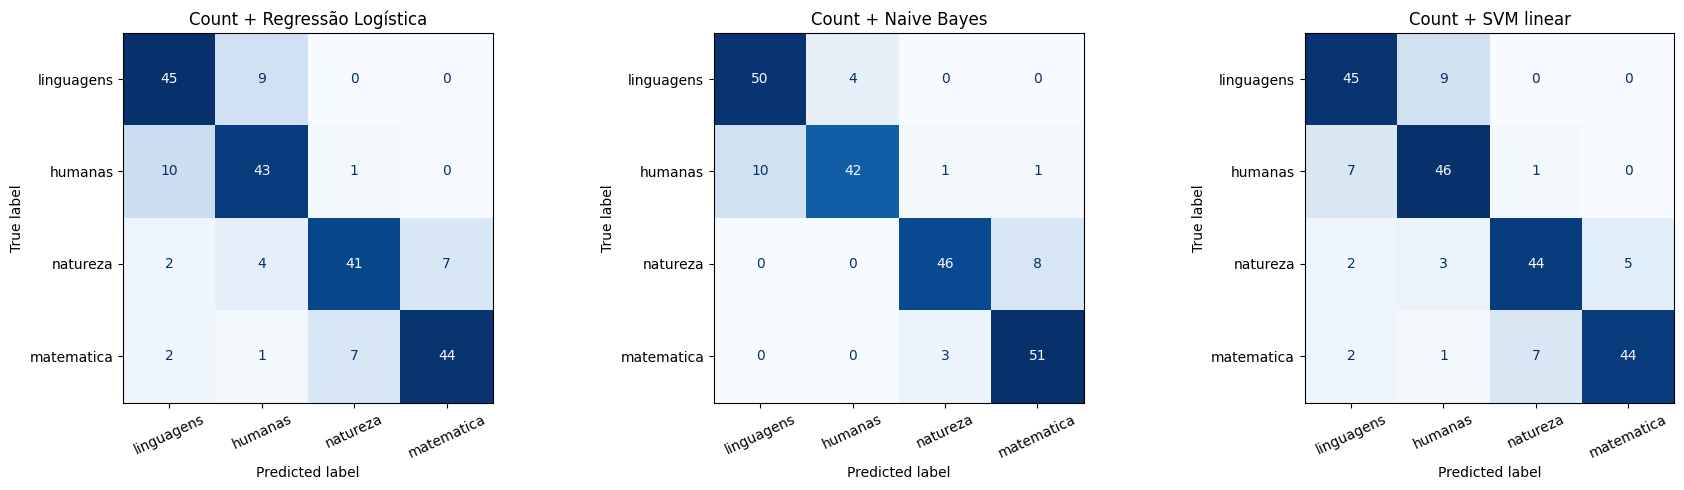

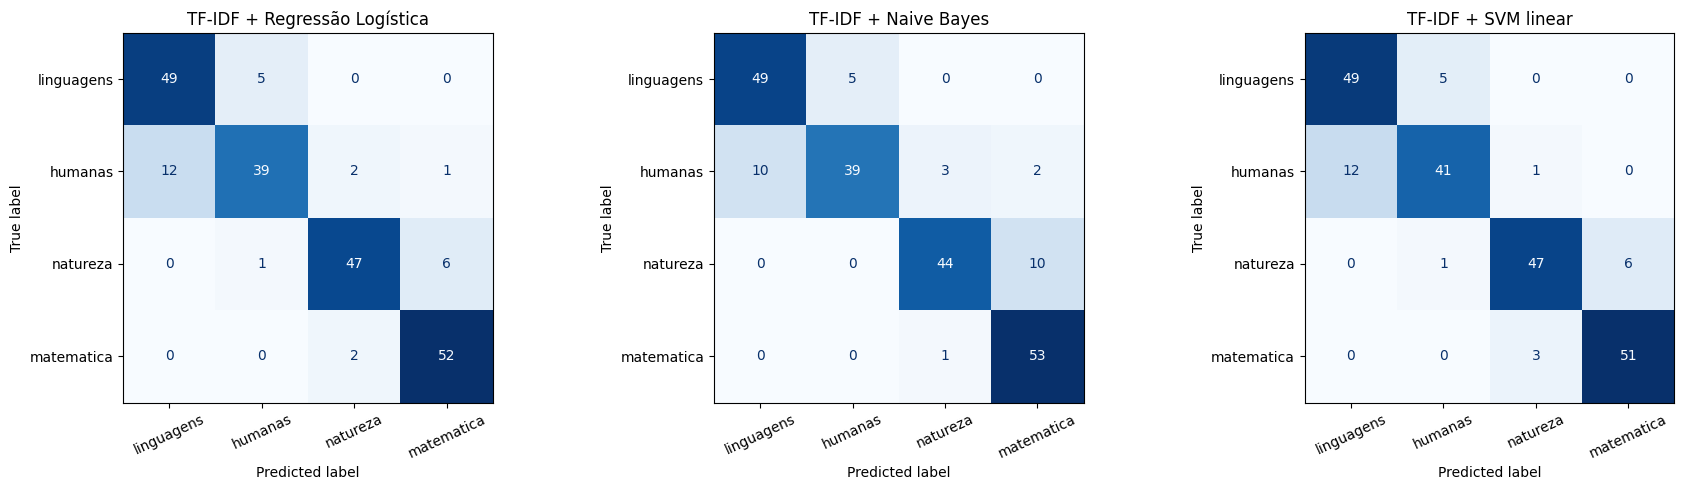

In [25]:
for nome_representacao in representacoes:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for eixo, nome_classificador in zip(axes, classificadores):
        chave = (nome_representacao, nome_classificador)
        exibicao = ConfusionMatrixDisplay(
            confusion_matrix=matrizes_confusao[chave],
            display_labels=classes,
        )
        exibicao.plot(ax=eixo, cmap="Blues", colorbar=False, values_format="d")
        eixo.set_title(f"{nome_representacao} + {nome_classificador}")
        eixo.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()

### Resultados da validação cruzada e do teste

Na validação cruzada, o melhor resultado foi do SVM com TF-IDF, que alcançou F1 macro de 0,8846. Já no conjunto de teste, o melhor modelo foi o Naive Bayes com CountVectorizer, com F1 macro de 0,8741 e acurácia de 0,8750. Esse resultado ficou próximo do F1 macro de 0,8713 obtido pelo mesmo modelo na validação.

O TF-IDF apresentou resultados melhores que o CountVectorizer com a Regressão Logística e o SVM. Com o Naive Bayes aconteceu o contrário: o CountVectorizer alcançou F1 macro de 0,8741, enquanto o TF-IDF obteve 0,8542. O SVM com TF-IDF ficou próximo do melhor resultado no teste, com F1 macro de 0,8696.

### Erros nas matrizes

As confusões mais recorrentes apareceram entre Linguagens e Humanas e entre Natureza e Matemática. No Naive Bayes com Count, 10 questões de Humanas foram classificadas como Linguagens e 8 de Natureza foram classificadas como Matemática.

Nesse modelo, Matemática teve 51 acertos, Linguagens 50, Natureza 46 e Humanas 42. O SVM com TF-IDF apresentou um padrão parecido: 12 erros de Humanas para Linguagens e 6 de Natureza para Matemática.

### Conclusão da questão 2

Entre as seis configurações, Naive Bayes com Count foi a melhor pelo F1 macro no teste. Além de alcançar 0,8741, ficou estável em relação à validação cruzada e manteve bons acertos nas quatro classes, embora Humanas tenha sido a classe mais difícil.

O SVM com TF-IDF foi o melhor na validação e teve resultado próximo no teste, mas não superou o Naive Bayes com Count. Os valores não indicam desempenho anormal ou algum sinal evidente de vazamento.

# Questão 3

Vamos comparar o NMF e o BERTopic para identificar os principais tópicos presentes nas questões. Nos dois métodos, usamos uma representação TF-IDF dos textos.

Escolhemos o NMF como método clássico porque ele pode ser aplicado diretamente à matriz TF-IDF, que possui apenas valores não negativos. Além disso, é possível interpretar os tópicos observando as palavras que possuem os maiores pesos em cada componente.

In [ ]:
import os
from pathlib import Path

# config pra evitar bug do numba -> acabei tendo... kkkkk -> isso resolve!
tmp_q3 = Path.cwd().parent / '.q3_tmp'
cache_numba_q3 = Path.cwd().parent / '.q3_numba_cache'
tmp_q3.mkdir(exist_ok=True)
cache_numba_q3.mkdir(exist_ok=True)
os.environ['TEMP'] = str(tmp_q3)
os.environ['TMP'] = str(tmp_q3)
os.environ['NUMBA_CACHE_DIR'] = str(cache_numba_q3)

import numpy as np
import pandas as pd
from IPython.display import display
from nltk.corpus import stopwords
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

df = pd.read_csv('data/questions_data_set_clean.csv', sep=';', encoding='utf-8-sig', dtype=str)

In [2]:
docs = df['texto'].astype(str).tolist()

stopwords_topicos = set(stopwords.words('portuguese'))
stopwords_topicos.update(stopwords.words('english'))
stopwords_topicos.update({'aa', 'bb', 'cc', 'dd', 'ee'})

tfidf_topicos = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 1),
    stop_words=sorted(stopwords_topicos),
    min_df=3,
    max_df=0.85
)
matriz_tfidf_topicos = tfidf_topicos.fit_transform(docs)

Na modelagem de tópicos removemos stopwords porque queremos que as palavras principais representem o conteúdo dos temas. Sem isso, palavras muito comuns poderiam aparecer entre as cinco palavras de vários tópicos.

Usamos "min_df=3" para evitar termos que aparecem em apenas uma ou duas questões e "max_df=0.85" para retirar termos presentes em quase toda a coleção e com pouco poder temático.

In [3]:
analyzer = tfidf_topicos.build_analyzer()
textos_tokenizados = [analyzer(texto) for texto in docs]
dictionary = Dictionary(textos_tokenizados)

print(f'Documentos: {len(docs)}')
print(f'Vocabulário: {len(tfidf_topicos.get_feature_names_out())} termos')
print(f'Formato da matriz TF-IDF: {matriz_tfidf_topicos.shape}')

Documentos: 720
Vocabulário: 4180 termos
Formato da matriz TF-IDF: (720, 4180)


## Escolha do número de tópicos

Testamos 4, 6, 8, 10 e 12 tópicos. Para cada valor calculamos a coerência "c_v" e a diversidade das dez palavras principais. A coerência ajuda a verificar se as palavras de um tópico aparecem em contextos relacionados, enquanto a diversidade mostra quanto as listas repetem palavras.

In [4]:
termos_topicos = np.array(tfidf_topicos.get_feature_names_out())

def palavras_nmf(modelo, quantidade=10):
    return [termos_topicos[componente.argsort()[-quantidade:][::-1]].tolist() for componente in modelo.components_]

def calcular_coerencia(topicos_palavras):
    return CoherenceModel(
        topics=topicos_palavras,
        texts=textos_tokenizados,
        dictionary=dictionary,
        coherence='c_v',
        processes=1
    ).get_coherence()

def calcular_diversidade(topicos_palavras, quantidade=10):
    palavras_unicas = set(palavra for topico in topicos_palavras for palavra in topico[:quantidade])
    return len(palavras_unicas) / (len(topicos_palavras) * quantidade)

valores_k = [4, 6, 8, 10, 12]
modelos_nmf = {}
palavras_candidatos = {}
resultados_k = []

for k in valores_k:
    modelo = NMF(n_components=k, init='nndsvda', random_state=42, max_iter=500)
    modelo.fit(matriz_tfidf_topicos)
    palavras = palavras_nmf(modelo, quantidade=10)
    modelos_nmf[k] = modelo
    palavras_candidatos[k] = palavras
    resultados_k.append({
        'Número de tópicos': k,
        'Coerência c_v': calcular_coerencia(palavras),
        'Diversidade': calcular_diversidade(palavras)
    })

In [5]:
tabela_k = pd.DataFrame(resultados_k)
display(tabela_k.style.format({'Coerência c_v': '{:.4f}', 'Diversidade': '{:.4f}'}).hide(axis='index'))

Número de tópicos,Coerência c_v,Diversidade
4,0.6414,0.9250
6,0.5958,0.9500
8,0.5476,0.9125
10,0.5040,0.9100
12,0.5304,0.9250


In [6]:
ks_interessantes = tabela_k.nlargest(3, 'Coerência c_v')['Número de tópicos'].tolist()
detalhes_candidatos = pd.DataFrame([
    {'k': k, 'Tópico': topico, '5 palavras principais': ', '.join(palavras[:5])}
    for k in ks_interessantes
    for topico, palavras in enumerate(palavras_candidatos[k])
])
display(detalhes_candidatos.style.hide(axis='index'))

k,Tópico,5 palavras principais
4,0,"texto, sobre, anos, mundo, vida"
4,1,"igual, água, figura, 10, centímetros"
4,2,"parêntese, fecha, abre, vezes, elevado"
4,3,"índice, menor, pontos, igual, circunferência"
6,0,"texto, sobre, mundo, anos, vida"
6,1,"igual, figura, centímetros, ponto, metros"
6,2,"parêntese, fecha, abre, vezes, elevado"
6,3,"índice, menor, pontos, circunferência, solução"
6,4,"água, energia, carga, temperatura, química"
6,5,"reais, cento, valor, 10, cada"


O maior valor de coerência apareceu com 4 tópicos ("0,6414"), mas essa divisão juntou em um mesmo grupo termos de medidas, figuras e água. Com 6 tópicos a coerência continuou alta ("0,5958") e a diversidade foi a maior entre os candidatos ("0,9500"). Também surgiram grupos separados para medidas geométricas, notação de fórmulas, fenômenos de Natureza e valores monetários.

Com 8 tópicos a coerência caiu para "0,5476" e houve mais repetição entre grupos ligados a fórmulas. Por esse equilíbrio entre métricas e interpretação, escolhemos "k_final = 6".

In [7]:
k_final = 6  # melhor equilíbrio entre coerência, diversidade e interpretação
nmf_final = NMF(n_components=k_final, init='nndsvda', random_state=42, max_iter=500)
W_nmf = nmf_final.fit_transform(matriz_tfidf_topicos)
H_nmf = nmf_final.components_
palavras_nmf_10 = palavras_nmf(nmf_final, quantidade=10)
palavras_nmf_5 = [palavras[:5] for palavras in palavras_nmf_10]

tabela_topicos_nmf = pd.DataFrame({
    'Tópico': range(k_final),
    '5 palavras mais relevantes': [', '.join(p) for p in palavras_nmf_5]
})
display(tabela_topicos_nmf.style.hide(axis='index'))

Tópico,5 palavras mais relevantes
0,"texto, sobre, mundo, anos, vida"
1,"igual, figura, centímetros, ponto, metros"
2,"parêntese, fecha, abre, vezes, elevado"
3,"índice, menor, pontos, circunferência, solução"
4,"água, energia, carga, temperatura, química"
5,"reais, cento, valor, 10, cada"


Os tópicos 1 e 3 estão ligados a medidas e geometria, enquanto o tópico 2 reúne marcas de expressões matemáticas. O tópico 4 é o mais claro para fenômenos de Física e Química, e o tópico 5 reúne valores e quantidades. O tópico 0 ficou mais genérico, com palavras comuns em textos de Linguagens e Humanas.

In [8]:
ids_selecionados_q3 = [
    'regular-2020-dia1_10',
    'regular-2023-dia1_60',
    'regular-2024-dia2_110',
    'regular-2025-dia2_150',
    'regular-2020-dia2_96'
]

posicoes_q3 = df.reset_index().set_index('ID')['index']
linhas_nmf = []
for doc_id in ids_selecionados_q3:
    indice = int(posicoes_q3.loc[doc_id])
    topico = int(np.argmax(W_nmf[indice]))
    linhas_nmf.append({
        'Documento': doc_id,
        'Trecho': docs[indice][:90] + ('...' if len(docs[indice]) > 90 else ''),
        'Tópico NMF': topico,
        'Peso': W_nmf[indice, topico],
        '5 palavras': ', '.join(palavras_nmf_5[topico])
    })
tabela_docs_nmf = pd.DataFrame(linhas_nmf)
display(tabela_docs_nmf.style.format({'Peso': '{:.4f}'}).hide(axis='index'))

Documento,Trecho,Tópico NMF,Peso,5 palavras
regular-2020-dia1_10,Os ratos Dyonélio Machado — O senhor pensa que eu tenho alguma fábrica de dinheiro? (O dir...,0,0.0697,"texto, sobre, mundo, anos, vida"
regular-2023-dia1_60,Quem se mete pelo caminho do pedido de perdão deve estar pronto a escutar uma palavra de r...,0,0.0523,"texto, sobre, mundo, anos, vida"
regular-2024-dia2_110,"Mirascópio 3D: produtor de ilusão instantânea O equipamento ilustrado na figura, de dimens...",1,0.1724,"igual, figura, centímetros, ponto, metros"
regular-2025-dia2_150,Quatro candidatos se apresentaram para realizar a prova de um concurso. Antes de iniciar a...,5,0.0546,"reais, cento, valor, 10, cada"
regular-2020-dia2_96,"Durante a realização de uma partida de futebol, os jogadores perceberam que a bola estava ...",4,0.0625,"água, energia, carga, temperatura, química"


As duas questões textuais ficaram no tópico 0, que é amplo e por isso explica pouco sobre o assunto de cada uma. A questão do mirascópio teve a associação mais clara, pois foi ligada a figura, centímetros, ponto e metros. A questão dos candidatos ficou no grupo de valores e quantidades, e a questão da bomba de futebol foi associada ao tópico de energia e temperatura. Esses três casos são coerentes, embora os pesos dos dois últimos sejam baixos.

## BERTopic

Para manter a mesma representação nos dois métodos, usamos a matriz TF-IDF também no BERTopic. A partir dela, o método agrupa os documentos e utiliza o c-TF-IDF para encontrar as palavras mais representativas de cada tópico. Nessa etapa, não usamos embeddings de transformers.

In [9]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP

umap_model = UMAP(
    n_neighbors=15, n_components=5, min_dist=0.0,
    metric='hellinger', random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=10, min_samples=5, metric='euclidean',
    cluster_selection_method='eom', prediction_data=True
)
vectorizer_bertopic = CountVectorizer(
    lowercase=True, stop_words=sorted(stopwords_topicos)
)
topic_model = BERTopic(
    embedding_model=None,
    language='multilingual',
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_bertopic,
    calculate_probabilities=False,
    verbose=False
)
topics_bertopic, probs_bertopic = topic_model.fit_transform(docs, matriz_tfidf_topicos)

In [10]:
info_bertopic_inicial = topic_model.get_topic_info().copy()
topicos_validos_iniciais = sorted(t for t in set(topics_bertopic) if t != -1)
n_topicos_bertopic_inicial = len(topicos_validos_iniciais)
n_outliers_bertopic = int(np.sum(np.array(topics_bertopic) == -1))
percentual_outliers = 100 * n_outliers_bertopic / len(docs)

print(f'Tópicos iniciais, sem contar -1: {n_topicos_bertopic_inicial}')
print(f'Outliers: {n_outliers_bertopic} de {len(docs)} documentos ({percentual_outliers:.2f}%)')
display(info_bertopic_inicial[['Topic', 'Count', 'Name']].style.hide(axis='index'))

Tópicos iniciais, sem contar -1: 6
Outliers: 76 de 720 documentos (10.56%)


Topic,Count,Name
-1,76,-1_igual_okosa_descrição_tipo
0,327,0_texto_sobre_vida_mundo
1,121,1_água_carga_energia_descrição
2,72,2_ponto_índice_figura_centímetros
3,55,3_reais_cada_cento_quantidade
4,53,4_parêntese_vezes_fecha_abre
5,16,5_segundos_quilômetros_quilômetro_hora


In [11]:
palavras_bertopic_iniciais = {
    topico: [palavra for palavra, peso in topic_model.get_topic(topico)[:5]]
    for topico in topicos_validos_iniciais
}
tabela_topicos_bertopic_iniciais = pd.DataFrame([
    {'Tópico inicial': topico, '5 palavras mais relevantes': ', '.join(palavras)}
    for topico, palavras in palavras_bertopic_iniciais.items()
])
display(tabela_topicos_bertopic_iniciais.style.hide(axis='index'))

Tópico inicial,5 palavras mais relevantes
0,"texto, sobre, vida, mundo, social"
1,"água, carga, energia, descrição, temperatura"
2,"ponto, índice, figura, centímetros, descrição"
3,"reais, cada, cento, quantidade, produção"
4,"parêntese, vezes, fecha, abre, fração"
5,"segundos, quilômetros, quilômetro, hora, tempo"


Como escolhemos 6 tópicos para representar a base e o BERTopic também encontrou 6 grupos, comparamos os dois métodos na mesma granularidade sem precisar de redução.

In [12]:
houve_reducao = n_topicos_bertopic_inicial > k_final
if houve_reducao:
    # Nesta versão, nr_topics inclui o grupo -1 quando há outliers.
    alvo_reducao_bertopic = k_final + int(-1 in topics_bertopic)
    topic_model.reduce_topics(docs, nr_topics=alvo_reducao_bertopic, use_ctfidf=True)
topics_bertopic_final = list(topic_model.topics_)
topicos_validos_bertopic = sorted(t for t in set(topics_bertopic_final) if t != -1)
n_topicos_bertopic_final = len(topicos_validos_bertopic)

print(f'Redução aplicada: {"sim" if houve_reducao else "não"}')
print(f'Tópicos finais, sem contar -1: {n_topicos_bertopic_final}')

Redução aplicada: não
Tópicos finais, sem contar -1: 6


In [13]:
palavras_bertopic_10 = {
    topico: [palavra for palavra, peso in topic_model.get_topic(topico)[:10]]
    for topico in topicos_validos_bertopic
}
palavras_bertopic_5 = {topico: palavras[:5] for topico, palavras in palavras_bertopic_10.items()}
tabela_topicos_bertopic = pd.DataFrame([
    {'Tópico': topico, '5 palavras mais relevantes': ', '.join(palavras_bertopic_5[topico])}
    for topico in topicos_validos_bertopic
])
display(tabela_topicos_bertopic.style.hide(axis='index'))

Tópico,5 palavras mais relevantes
0,"texto, sobre, vida, mundo, social"
1,"água, carga, energia, descrição, temperatura"
2,"ponto, índice, figura, centímetros, descrição"
3,"reais, cada, cento, quantidade, produção"
4,"parêntese, vezes, fecha, abre, fração"
5,"segundos, quilômetros, quilômetro, hora, tempo"


In [14]:
posicoes_ids_q3 = [int(posicoes_q3.loc[doc_id]) for doc_id in ids_selecionados_q3]
ha_outlier_selecionado = any(topics_bertopic_final[i] == -1 for i in posicoes_ids_q3)
topics_reassociados = None
if ha_outlier_selecionado:
    topics_reassociados = topic_model.reduce_outliers(
        docs, topics_bertopic_final, strategy='c-tf-idf'
    )

linhas_bertopic = []
for doc_id, indice in zip(ids_selecionados_q3, posicoes_ids_q3):
    topico_original = int(topics_bertopic_final[indice])
    if topico_original == -1:
        topico_mostrado = int(topics_reassociados[indice])
        situacao = 'outlier reassociado'
    else:
        topico_mostrado = topico_original
        situacao = 'cluster original'
    linhas_bertopic.append({
        'Documento': doc_id,
        'Tópico BERTopic': topico_mostrado,
        'Situação': situacao,
        '5 palavras': ', '.join(palavras_bertopic_5.get(topico_mostrado, []))
    })
tabela_docs_bertopic = pd.DataFrame(linhas_bertopic)
display(tabela_docs_bertopic.style.hide(axis='index'))

Documento,Tópico BERTopic,Situação,5 palavras
regular-2020-dia1_10,0,cluster original,"texto, sobre, vida, mundo, social"
regular-2023-dia1_60,0,cluster original,"texto, sobre, vida, mundo, social"
regular-2024-dia2_110,2,cluster original,"ponto, índice, figura, centímetros, descrição"
regular-2025-dia2_150,3,cluster original,"reais, cada, cento, quantidade, produção"
regular-2020-dia2_96,1,cluster original,"água, carga, energia, descrição, temperatura"


Os cinco documentos ficaram em clusters originais, sem necessidade de reassociação. As duas questões textuais foram associadas ao tópico 0. O mirascópio ficou no tópico de ponto, figura e centímetros, enquanto a questão dos candidatos foi ligada a valores e quantidades. A bomba de futebol apareceu no tópico de água, carga, energia e temperatura. As três últimas associações combinam diretamente com o conteúdo dos documentos.

In [15]:
topicos_bertopic_coerencia = [
    [palavra for palavra in palavras_bertopic_10[topico] if palavra in dictionary.token2id]
    for topico in topicos_validos_bertopic
]
topicos_bertopic_coerencia = [palavras for palavras in topicos_bertopic_coerencia if palavras]

coerencia_nmf = calcular_coerencia(palavras_nmf_10)
diversidade_nmf = calcular_diversidade(palavras_nmf_10)
coerencia_bertopic = calcular_coerencia(topicos_bertopic_coerencia)
diversidade_bertopic = calcular_diversidade(
    [palavras_bertopic_10[t] for t in topicos_validos_bertopic]
)

tabela_comparacao_metodos = pd.DataFrame([
    {'Método': 'NMF', 'Nº tópicos final': k_final, 'Coerência c_v': coerencia_nmf,
     'Diversidade': diversidade_nmf, 'Outliers': 0},
    {'Método': 'BERTopic', 'Nº tópicos final': n_topicos_bertopic_final, 'Coerência c_v': coerencia_bertopic,
     'Diversidade': diversidade_bertopic, 'Outliers': n_outliers_bertopic}
])
display(tabela_comparacao_metodos.style.format({
    'Coerência c_v': '{:.4f}', 'Diversidade': '{:.4f}'
}).hide(axis='index'))

Método,Nº tópicos final,Coerência c_v,Diversidade,Outliers
NMF,6,0.5958,0.9500,0
BERTopic,6,0.6231,0.9667,76


In [16]:
tabela_comparacao_documentos = (
    tabela_docs_nmf[['Documento', 'Tópico NMF', '5 palavras']]
    .rename(columns={'5 palavras': 'Palavras NMF'})
    .merge(
        tabela_docs_bertopic[['Documento', 'Tópico BERTopic', '5 palavras']]
        .rename(columns={'5 palavras': 'Palavras BERTopic'}),
        on='Documento'
    )
)
display(tabela_comparacao_documentos.style.hide(axis='index'))

Documento,Tópico NMF,Palavras NMF,Tópico BERTopic,Palavras BERTopic
regular-2020-dia1_10,0,"texto, sobre, mundo, anos, vida",0,"texto, sobre, vida, mundo, social"
regular-2023-dia1_60,0,"texto, sobre, mundo, anos, vida",0,"texto, sobre, vida, mundo, social"
regular-2024-dia2_110,1,"igual, figura, centímetros, ponto, metros",2,"ponto, índice, figura, centímetros, descrição"
regular-2025-dia2_150,5,"reais, cento, valor, 10, cada",3,"reais, cada, cento, quantidade, produção"
regular-2020-dia2_96,4,"água, energia, carga, temperatura, química",1,"água, carga, energia, descrição, temperatura"


### Conclusão da questão 3

O BERTopic alcançou coerência "c_v" de "0,6231", enquanto o NMF obteve "0,5958". A diversidade também foi maior no BERTopic, com "0,9667" contra "0,9500", o que mostra que houve menos repetição entre as palavras principais dos tópicos.

Os tópicos encontrados pelo BERTopic foram fáceis de interpretar. Apareceram grupos relacionados a textos sociais, fenômenos de Natureza, geometria e medidas, valores, fórmulas e velocidade. Entre os cinco documentos analisados, o mirascópio, a questão dos candidatos e a bomba de futebol foram associados a grupos que combinam com seus conteúdos. Nenhum dos cinco documentos foi classificado como outlier.

O BERTopic encontrou 6 tópicos desde o início, então não foi necessário reduzir ou juntar grupos. Mesmo assim, 76 dos 720 documentos foram classificados como outliers, o que representa "10,56%" da base. Já o NMF conseguiu atribuir pesos de tópicos a todos os documentos.

Nessa análise, consideramos o BERTopic o melhor método. Ele apresentou valores maiores de coerência e diversidade e gerou associações mais específicas para os cinco exemplos. Sua principal limitação foi a quantidade de documentos classificados como outliers.